El dataset  muestra el comportamiento y características psicológicas, sociales y de rendimiento de jugadores, con el fin de detectar adicción a los videojuegos. Puede realizarse un enfoque segun estudio con `addiction_score` como variable continua, `addiction_binary` como una clasificación binaria y `addiction_severity` como categórica ordinal.

La matriz cuenta con 250 entradas y 49 columnas detalladas a continuación:

Comportamiento de juego:
- `years_gaming`, `daily_playtime_hours`, `weekly_play_sessions`, `late_night_sessions_hours`, `weekend_playtime_hours`, `consecutive_hours_max`, `multiplayer_ratio`

Perfil del jugador:
- `age`, `gender`, `country`, `occupation`, `income_level`, `platform`, `device_type`, `rank_tier`, `preferred_genre`

Conducta en juego:
- `toxic_chat_reports`, `rage_quit_frequency`, `in_game_purchases`, `monthly_spending_usd`, `lootbox_openings`, `subscription_status`

Psicologia:
- `stress_score`, `loneliness_score`, `dopamine_dependency_index`, `self_control_score`, `impulsiveness_score`, `anxiety_level`, `depression_indicator`, `emotional_stability`, `burnout_probability`, `mental_health_risk_score`

Habitos:
- `sleep_hours`, `exercise_frequency_per_week`, `caffeine_intake_cups_day`, `social_interaction_hours`, `relationship_status`

Rendimiento profesional:
- `gpa_or_performance_score`, `missed_deadlines`, `productivity_drop_percent`, `absenteeism_days`

Fuente: https://www.kaggle.com/datasets/laveshjadon/gaming-addiction-dataset

## Sección 0 — Configuración inicial

In [2]:
# ============================================================
#   PARÁMETROS
# ============================================================
FILEPATH     = 'dataset2_gaming_addiction.csv'
TARGET       = 'addiction_binary'
TEST_SIZE    = 0.2
RANDOM_STATE = 42


In [4]:
# ============================================================
#   IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection  import (train_test_split, cross_val_score,
                                       StratifiedKFold, GridSearchCV, RandomizedSearchCV)
from sklearn.pipeline         import Pipeline
from sklearn.compose          import ColumnTransformer
from sklearn.preprocessing    import StandardScaler, OneHotEncoder
from sklearn.impute           import SimpleImputer
from sklearn.linear_model     import LogisticRegression
from sklearn.neighbors        import KNeighborsClassifier
from sklearn.tree             import DecisionTreeClassifier
from sklearn.ensemble         import RandomForestClassifier
from sklearn.pipeline         import make_pipeline
from sklearn.preprocessing    import MinMaxScaler
from sklearn.metrics          import (accuracy_score, precision_score, recall_score,
                                       f1_score, roc_auc_score, classification_report,
                                       ConfusionMatrixDisplay, roc_curve)
from scipy.stats              import randint, uniform

print('✅ Imports OK')

✅ Imports OK


In [18]:
# ============================================================
#   CARGA DE DATOS
# ============================================================
df = pd.read_csv(FILEPATH)
df = df.reset_index(drop=True)
df = df.drop(columns='user_id')

print(f'Shape: {df.shape}')
display(df.head())
print()
display(df.tail())

Shape: (250, 48)


,age,gender,country,occupation,income_level,years_gaming,preferred_genre,platform,device_type,rank_tier,...,absenteeism_days,internet_speed_mbps,screen_time_total_hours,behavioral_cluster,addiction_score,addiction_binary,addiction_severity,burnout_probability,mental_health_risk_score,churn_probability
0,21,Male,India,Employed,Middle,9,Sandbox,PC,Laptop,Gold,...,7,39.9,5.4,Casual Enjoyer,27.61,0,Mild,1.0,0.920,1.000
1,25,Male,India,Employed,Lower-Middle,13,RPG,Mobile,Mixed,Bronze,...,6,71.5,13.4,Streamer/Creator,55.51,1,Moderate,1.0,0.515,0.813
2,26,Male,Brazil,Employed,Middle,14,RPG,PC+Mobile,High-end PC,Master,...,7,119.4,12.3,Streamer/Creator,45.85,0,Moderate,1.0,0.720,0.947
3,22,Male,South Korea,Employed,Upper-Middle,10,Strategy,PC+Mobile,Mobile,Bronze,...,8,136.5,6.9,Toxic Competitor,39.87,0,Mild,1.0,0.520,0.660
4,17,Female,India,Student,Middle,5,Strategy,PC,Laptop,Bronze,...,6,78.8,9.3,Competitive Grinder,46.97,0,Moderate,1.0,0.585,0.867


,age,gender,country,occupation,income_level,years_gaming,preferred_genre,platform,device_type,rank_tier,...,absenteeism_days,internet_speed_mbps,screen_time_total_hours,behavioral_cluster,addiction_score,addiction_binary,addiction_severity,burnout_probability,mental_health_risk_score,churn_probability
245,23,Female,Japan,Streamer/Content Creator,Upper-Middle,11,MMORPG,PC+Console,Console,Platinum,...,4,180.9,7.2,Streamer/Creator,42.37,0,Moderate,1.0,0.395,0.590
246,18,Male,India,Student,Low,6,Sandbox,PC,Mid-range PC,Bronze,...,0,91.5,5.6,Social Gamer,22.45,0,Mild,1.0,0.715,0.803
247,20,Male,USA,Student,Middle,8,MMORPG,Mobile,Console,Bronze,...,8,120.6,4.9,Escape Seeker,34.76,0,Mild,1.0,0.410,0.939
248,19,Male,South Korea,Employed,Middle,7,Sandbox,PC+Console,High-end PC,Silver,...,2,175.9,5.2,Social Gamer,36.60,0,Mild,1.0,0.405,0.870
249,27,Male,USA,Unemployed,Middle,14,MMORPG,PC+Mobile,Laptop,Gold,...,4,131.7,4.8,Social Gamer,41.65,0,Moderate,1.0,0.605,0.733


---
## Sección I — Exploración y Limpieza (EDA)

### I.1 — Información general

In [7]:
print('================================= Info =================================')
df.info()
print()
print('================================= Describe =================================')
display(df.describe().T)
print('================================= Variables Categóricas =================================')
cat_cols = df.select_dtypes(include='object').columns
cat_stats = pd.DataFrame({
    'n_unique'  : df[cat_cols].nunique(),
    'moda'      : df[cat_cols].mode().iloc[0],
    'frec_moda' : df[cat_cols].apply(lambda x: x.value_counts().iloc[0]),
    'pct_moda'  : df[cat_cols].apply(lambda x: x.value_counts(normalize=True).iloc[0] * 100).round(1),
})
display(cat_stats)

# Tipos de datos correctos
# columnas numericas en rangos posibles
# analisis posterior a variables categoricas

================================= Info =================================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 48 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          250 non-null    int64  
 1   gender                       250 non-null    object 
 2   country                      250 non-null    object 
 3   occupation                   250 non-null    object 
 4   income_level                 250 non-null    object 
 5   years_gaming                 250 non-null    int64  
 6   preferred_genre              250 non-null    object 
 7   platform                     250 non-null    object 
 8   device_type                  250 non-null    object 
 9   rank_tier                    250 non-null    object 
 10  daily_playtime_hours         250 non-null    float64
 11  weekly_play_sessions         250 non-null    int64  
 12  late_

,count,mean,std,min,25%,50%,75%,max
age,250.0,22.160000,5.455037,13.00,18.00000,22.000,27.000,40.00
years_gaming,250.0,9.668000,5.460866,1.00,6.00000,9.000,14.750,25.00
daily_playtime_hours,250.0,6.153200,2.656902,0.50,4.22500,6.450,8.175,11.90
weekly_play_sessions,250.0,7.056000,3.517721,1.00,4.00000,7.000,10.000,15.00
late_night_sessions_hours,250.0,2.102400,1.200700,0.00,1.12500,2.100,3.000,5.20
weekend_playtime_hours,250.0,8.368400,4.085876,0.50,5.60000,8.150,10.850,20.00
consecutive_hours_max,250.0,9.714800,4.828877,1.00,5.52500,10.100,13.175,20.60
multiplayer_ratio,250.0,0.462240,0.227391,0.00,0.30000,0.450,0.630,1.00
toxic_chat_reports,250.0,2.948000,5.451621,0.00,0.00000,1.000,2.000,32.00
rage_quit_frequency,250.0,1.896000,2.353581,0.00,0.00000,1.000,3.000,10.00


================================= Variables Categóricas =================================


,n_unique,moda,frec_moda,pct_moda
gender,4,Male,158,63.2
country,15,USA,62,24.8
occupation,5,Employed,119,47.6
income_level,5,Middle,98,39.2
preferred_genre,10,MMORPG,39,15.6
platform,5,PC,103,41.2
device_type,6,Mixed,50,20.0
rank_tier,8,Gold,52,20.8
subscription_status,3,Premium,76,45.2
relationship_status,5,Single,110,44.0


### I.2 — Duplicados

In [8]:
n_dup = df.duplicated().sum()
print(f'Filas iniciales : {len(df)}')
print(f'Duplicados      : {n_dup} ({n_dup/len(df)*100:.2f}%)')

if n_dup > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f'Filas tras limpieza: {len(df)}')
else:
    print('Sin duplicados ✓')

Filas iniciales : 250
Duplicados      : 0 (0.00%)
Sin duplicados ✓


### I.3 — Nulos

In [19]:
nulos = df.isnull().sum()
pct   = (nulos / len(df) * 100).round(2)
nulos_df = pd.DataFrame({'nulos': nulos, 'porcentaje': pct}).query('nulos > 0')
display(nulos_df if not nulos_df.empty else pd.DataFrame({'resultado': ['Sin nulos ✓']}))

# eliminacion de filas donde el porcentaje es de menos de 5%
df = df.dropna(subset=['depression_indicator', 'gpa_or_performance_score'])

# columna subscription_status tiene un alto % de nulos y se considera irrelevante debido a la opcion de juegos sin suscripcion
# puede ser que datos nulos sean derechamente usuarion sin suscripcion, para este trabajo se eliminara la columna
df = df.drop(columns='subscription_status')

# addiction_severity puede ser uno de los target de este trabajo, por lo tanto pueden eliminarse los nulos de ser elegido o bien imputarse en el preprocesamiento

# nulos después de eliminacion
print()
nulos = df.isnull().sum()
pct   = (nulos / len(df) * 100).round(2)
nulos_df = pd.DataFrame({'nulos': nulos, 'porcentaje': pct}).query('nulos > 0')
display(nulos_df if not nulos_df.empty else pd.DataFrame({'resultado': ['Sin nulos ✓']}))

,nulos,porcentaje
subscription_status,82,32.8
depression_indicator,11,4.4
gpa_or_performance_score,10,4.0
addiction_severity,16,6.4


,nulos,porcentaje
addiction_severity,15,6.55


### I.4 — Inconsistencias categóricas

In [20]:
# no hay problemas con las columnas categoricas

cat_cols = df.select_dtypes(include='object').columns.tolist()
print('================================= Value Counts =================================\n')
for col in cat_cols:
    print(f'===== {col} =====')
    display(df[col].value_counts())
    print()

print('================================= Verificación de capitalización =================================\n')
for col in cat_cols:
    original = df[col].nunique()
    lower    = df[col].str.lower().nunique()
    if original != lower:
        print(f"  ⚠️  INCONSISTENCIA en '{col}': {original} vs {lower}")
        df[col] = df[col].str.strip().str.lower()
    else:
        print(f"  '{col}': sin inconsistencias ✓")

================================= Value Counts =================================

===== gender =====


,count
gender,
Male,147
Female,59
Non-binary,16
Prefer not to say,7



===== country =====


,count
country,
USA,58
India,39
Brazil,20
Germany,18
Russia,13
UK,12
Canada,11
Japan,11
Other,11



===== occupation =====


...


===== behavioral_cluster =====


,count
behavioral_cluster,
Casual Enjoyer,41
Streamer/Creator,36
Social Gamer,34
Escape Seeker,32
Toxic Competitor,31
Binge Player,28
Competitive Grinder,27



===== addiction_severity =====


,count
addiction_severity,
Moderate,105
Mild,104
Severe,5



================================= Verificación de capitalización =================================

  'gender': sin inconsistencias ✓
  'country': sin inconsistencias ✓
  'occupation': sin inconsistencias ✓
  'income_level': sin inconsistencias ✓
  'preferred_genre': sin inconsistencias ✓
  'platform': sin inconsistencias ✓
  'device_type': sin inconsistencias ✓
  'rank_tier': sin inconsistencias ✓
  'relationship_status': sin inconsistencias ✓
  'behavioral_cluster': sin inconsistencias ✓
  'addiction_severity': sin inconsistencias ✓


### I.5 — Outliers (IQR)

In [21]:
num_cols = df.select_dtypes(include='number').columns.tolist()

outlier_report = []
for col in num_cols:
    Q1    = df[col].quantile(0.25)
    Q3    = df[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_report.append({'columna': col, 'Q1': round(Q1,2), 'Q3': round(Q3,2),
                           'lim_inf': round(lower,2), 'lim_sup': round(upper,2),
                           'outliers': n_out, 'pct': round(n_out/len(df)*100,2)})
display(pd.DataFrame(outlier_report))


,columna,Q1,Q3,lim_inf,lim_sup,outliers,pct
0,age,18.00,27.00,4.50,40.50,0,0.00
1,years_gaming,6.00,14.00,-6.00,26.00,0,0.00
2,daily_playtime_hours,4.20,8.20,-1.80,14.20,0,0.00
3,weekly_play_sessions,5.00,10.00,-2.50,17.50,0,0.00
4,late_night_sessions_hours,1.20,3.00,-1.50,5.70,0,0.00
5,weekend_playtime_hours,5.60,10.70,-2.05,18.35,3,1.31
6,consecutive_hours_max,5.50,13.10,-5.90,24.50,0,0.00
7,multiplayer_ratio,0.30,0.62,-0.18,1.10,0,0.00
8,toxic_chat_reports,0.00,2.00,-3.00,5.00,36,15.72
9,rage_quit_frequency,0.00,3.00,-4.50,7.50,9,3.93


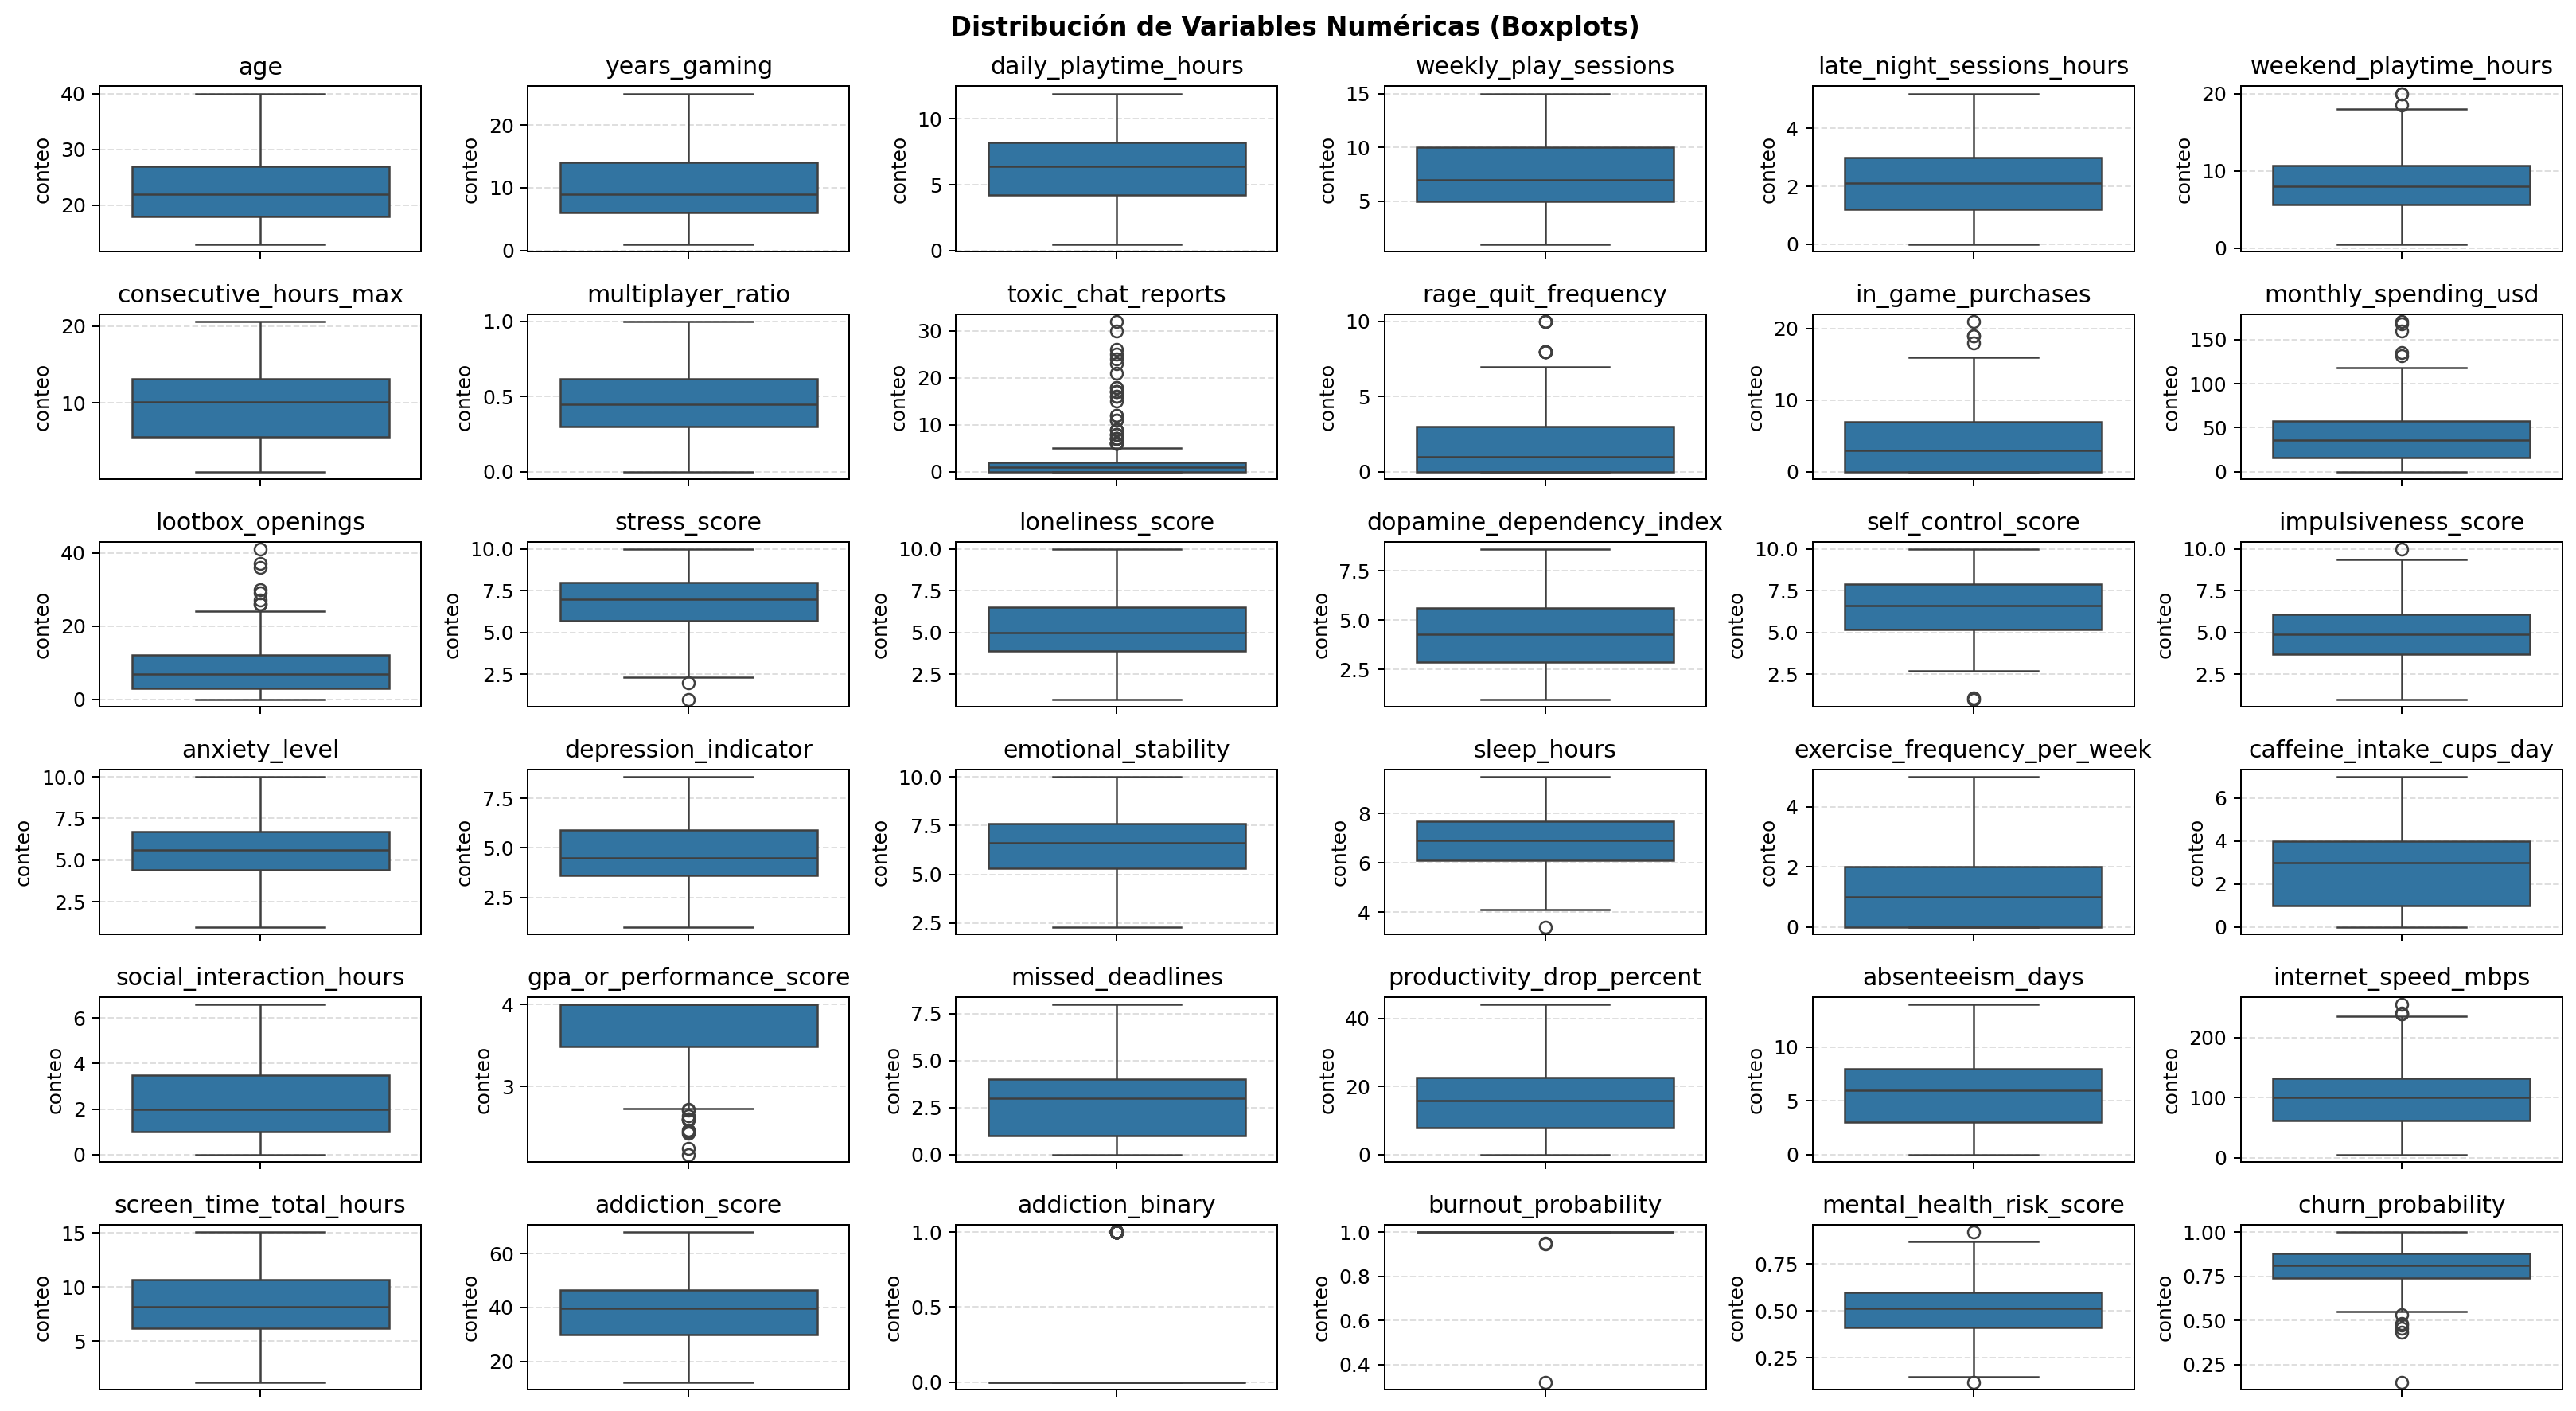

In [34]:
# boxplots  variables vs salud mental
fig, axes = plt.subplots(6, 6, figsize=(18, 10), dpi=180)
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(f'{col}')
    ax.set_ylabel('conteo')
    ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Distribución de Variables Numéricas (Boxplots)', fontsize=13, fontweight='bold')
print()
plt.tight_layout(); plt.show()

Aunque los outliers no estan presentes en todos los graficos, algunos puedes tener gran densidad de ellos, como el caso de monthly_spending_usd y consecutive_hours_max, en todos los casos los valores atipicos son perfectamente plausibles y corresponden a jugadores con habitos extremos que es el objetivo de este analisis por lo tanto se mantendran todos los outliers.

### I.6 — Visualizaciones

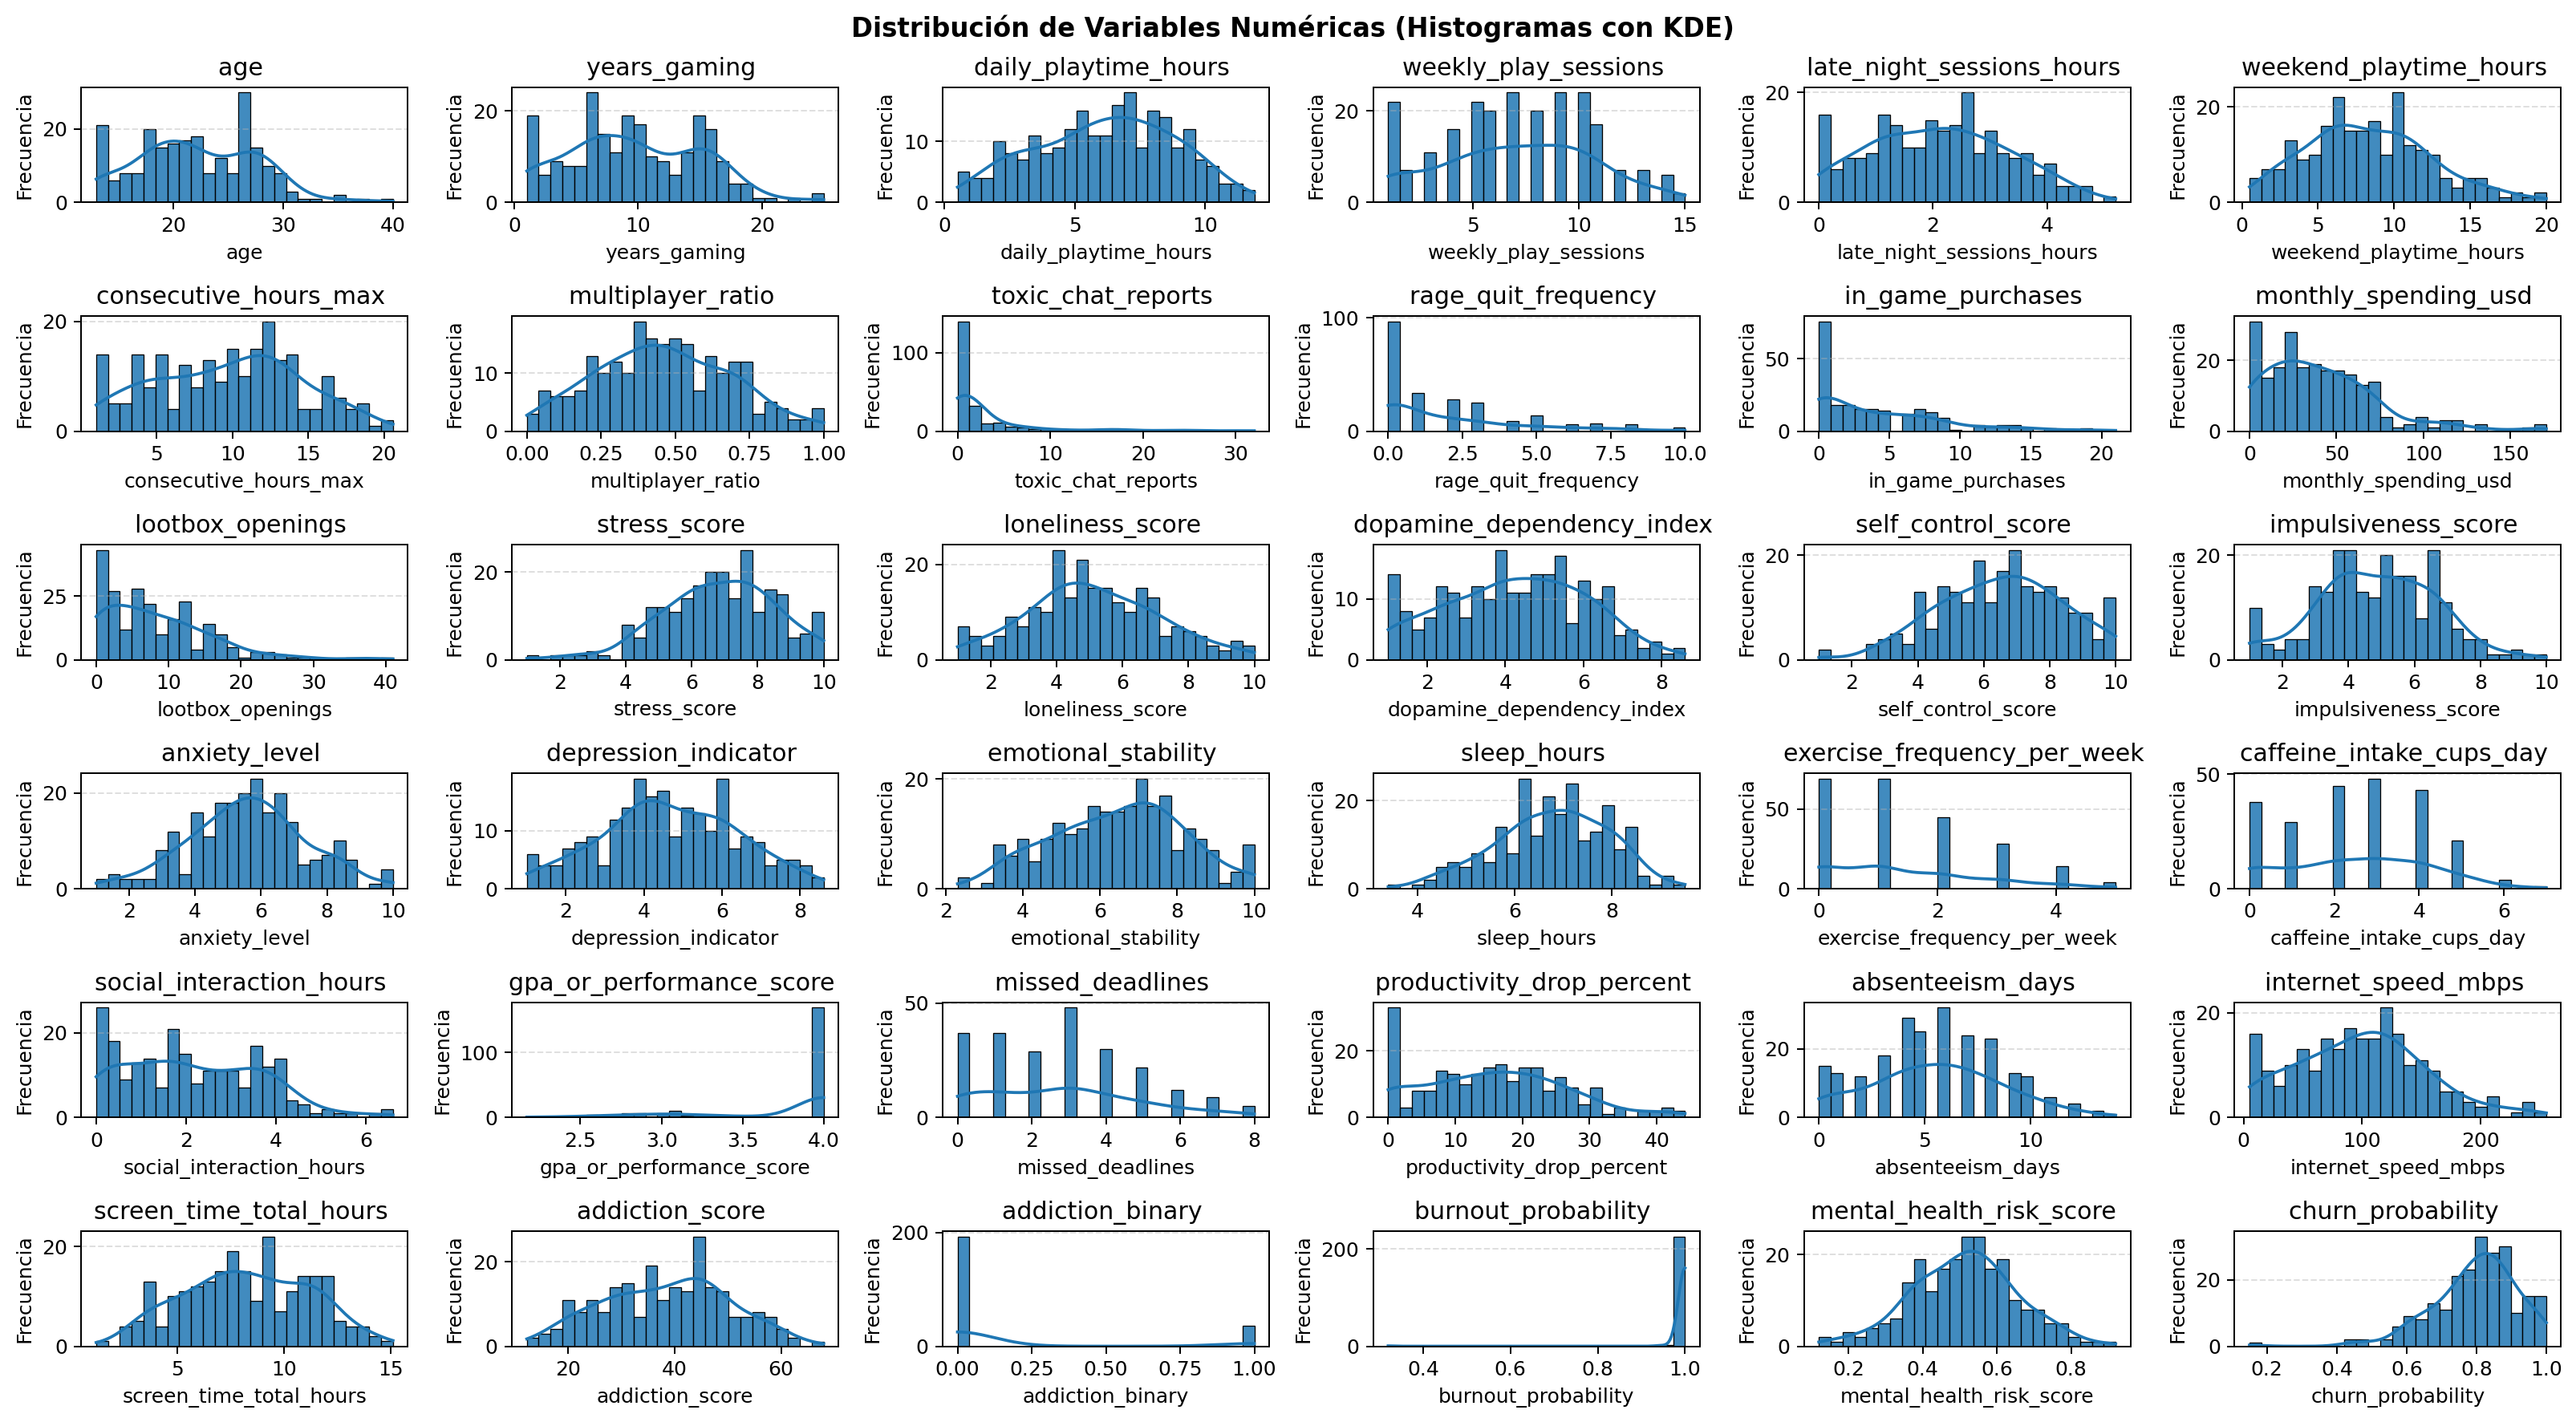

In [42]:
# Variables numericas
fig, axes = plt.subplots(6, 6, figsize=(18, 10), dpi=180)
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    sns.histplot(df[col], bins=25, ax=ax, kde=True, alpha=0.85)
    ax.set_title(f'{col} ')
    ax.set_xlabel(col); ax.set_ylabel('Frecuencia')
    ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Distribución de Variables Numéricas (Histogramas con KDE)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()



Existe una gran cantidad de variables que presentan una distribucion relativamente normal, el resto mayormente una distribucion desplazada a los numeros bajos. Casos particulares que llaman la atencion son:
* age: la muestra es mayoritariamente de gente de joven, que es la que presenta usualmente mayor problemas de addicion o donde estos tienden a generarse.
* pese a ser la mayoria gente joven, la distribucion de años en gaming es bastante dispersa, lo que indicaria que muchos de los casos son jugadores desde muy jovenes
* en consecutive_hours_max hay unos casos preocupantes de casi 20 horas continuas, esto ayudara al modelo a predecir modelos claros de addicion
* indicadoers de depresion, ansiedad, dopamina y sueño estan preocupantemente normalizados, siendo idealmente unas variables que gustaria estuvieran siempre en numero bajos para los primeros casos y el sueño en un promedio de 8 horas

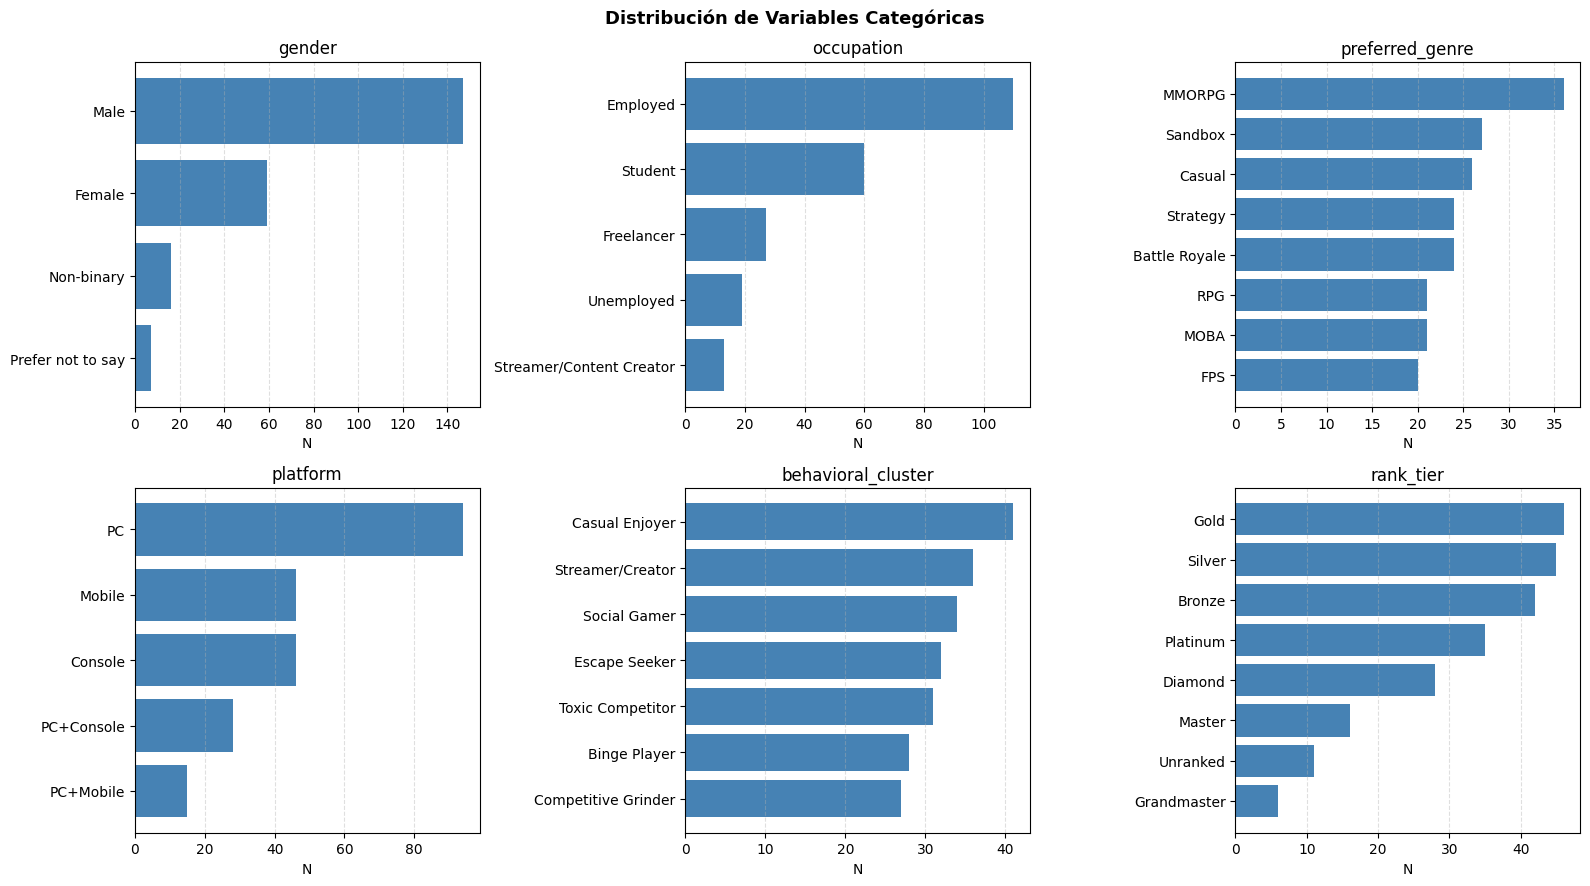

In [48]:
#variables categóricas
cat_viz = ['gender','occupation','preferred_genre','platform','behavioral_cluster','rank_tier']

fig, axes = plt.subplots(2, 3, figsize=(16, 9), dpi=100)
axes = axes.flatten()

for ax, col in zip(axes, cat_viz):
    top = df[col].value_counts().head(8)
    ax.barh(top.index[::-1], top.values[::-1], color='steelblue', edgecolor='none')
    ax.set_title(f'{col}')
    ax.set_xlabel('N')
    ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.suptitle('Distribución de Variables Categóricas', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

Predominancia del genero masculino, y en situacion de empleo, o sea gente que puede costearse el hobby. Algunos generos como MMORPG y sandbox suelen ser de los mas enviciantes, asique tiene sentido que esten en el top de generos preferidos.

### I.7 — Variable objetivo: addiction_binary

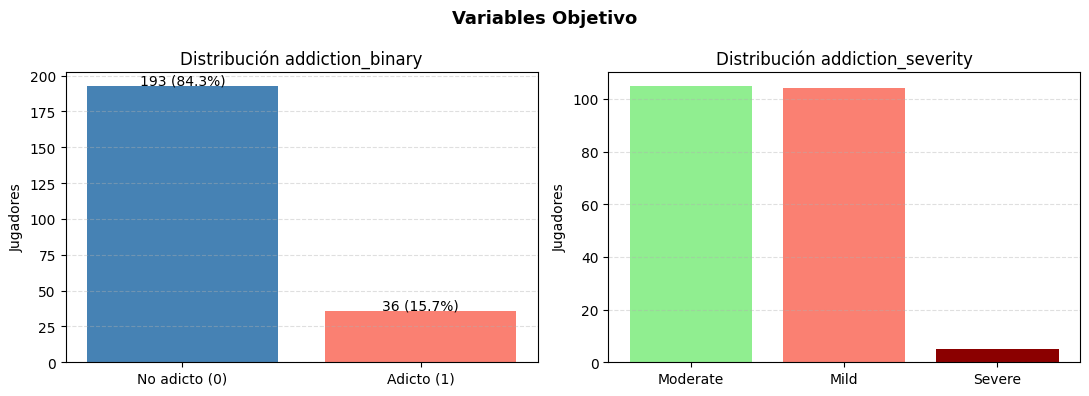

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), dpi=100)

# Binaria
counts = df['addiction_binary'].value_counts().sort_index()
axes[0].bar(['No adicto (0)', 'Adicto (1)'], counts.values,
            color=['steelblue', 'salmon'], edgecolor='none')
axes[0].set_title('Distribución addiction_binary', fontsize=12)
axes[0].set_ylabel('Jugadores')
axes[0].grid(axis='y', linestyle='--', alpha=0.4)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1, f'{v} ({v/len(df)*100:.1f}%)', ha='center', fontsize=10)

# Severidad
sev_counts = df['addiction_severity'].value_counts()
axes[1].bar(sev_counts.index, sev_counts.values,
            color=['lightgreen','salmon','darkred'], edgecolor='none')
axes[1].set_title('Distribución addiction_severity', fontsize=12)
axes[1].set_ylabel('Jugadores')
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Variables Objetivo', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


Matriz bastante desbalanceada, lo que es bueno a nivel psicologico pero no muy util para el modelo, se requerira estratificar para asegurar una buena prediccion. No es una adiccion tan comun y suele encontrarse dentro de estandares normales.

### I.8 — Heatmap correlación

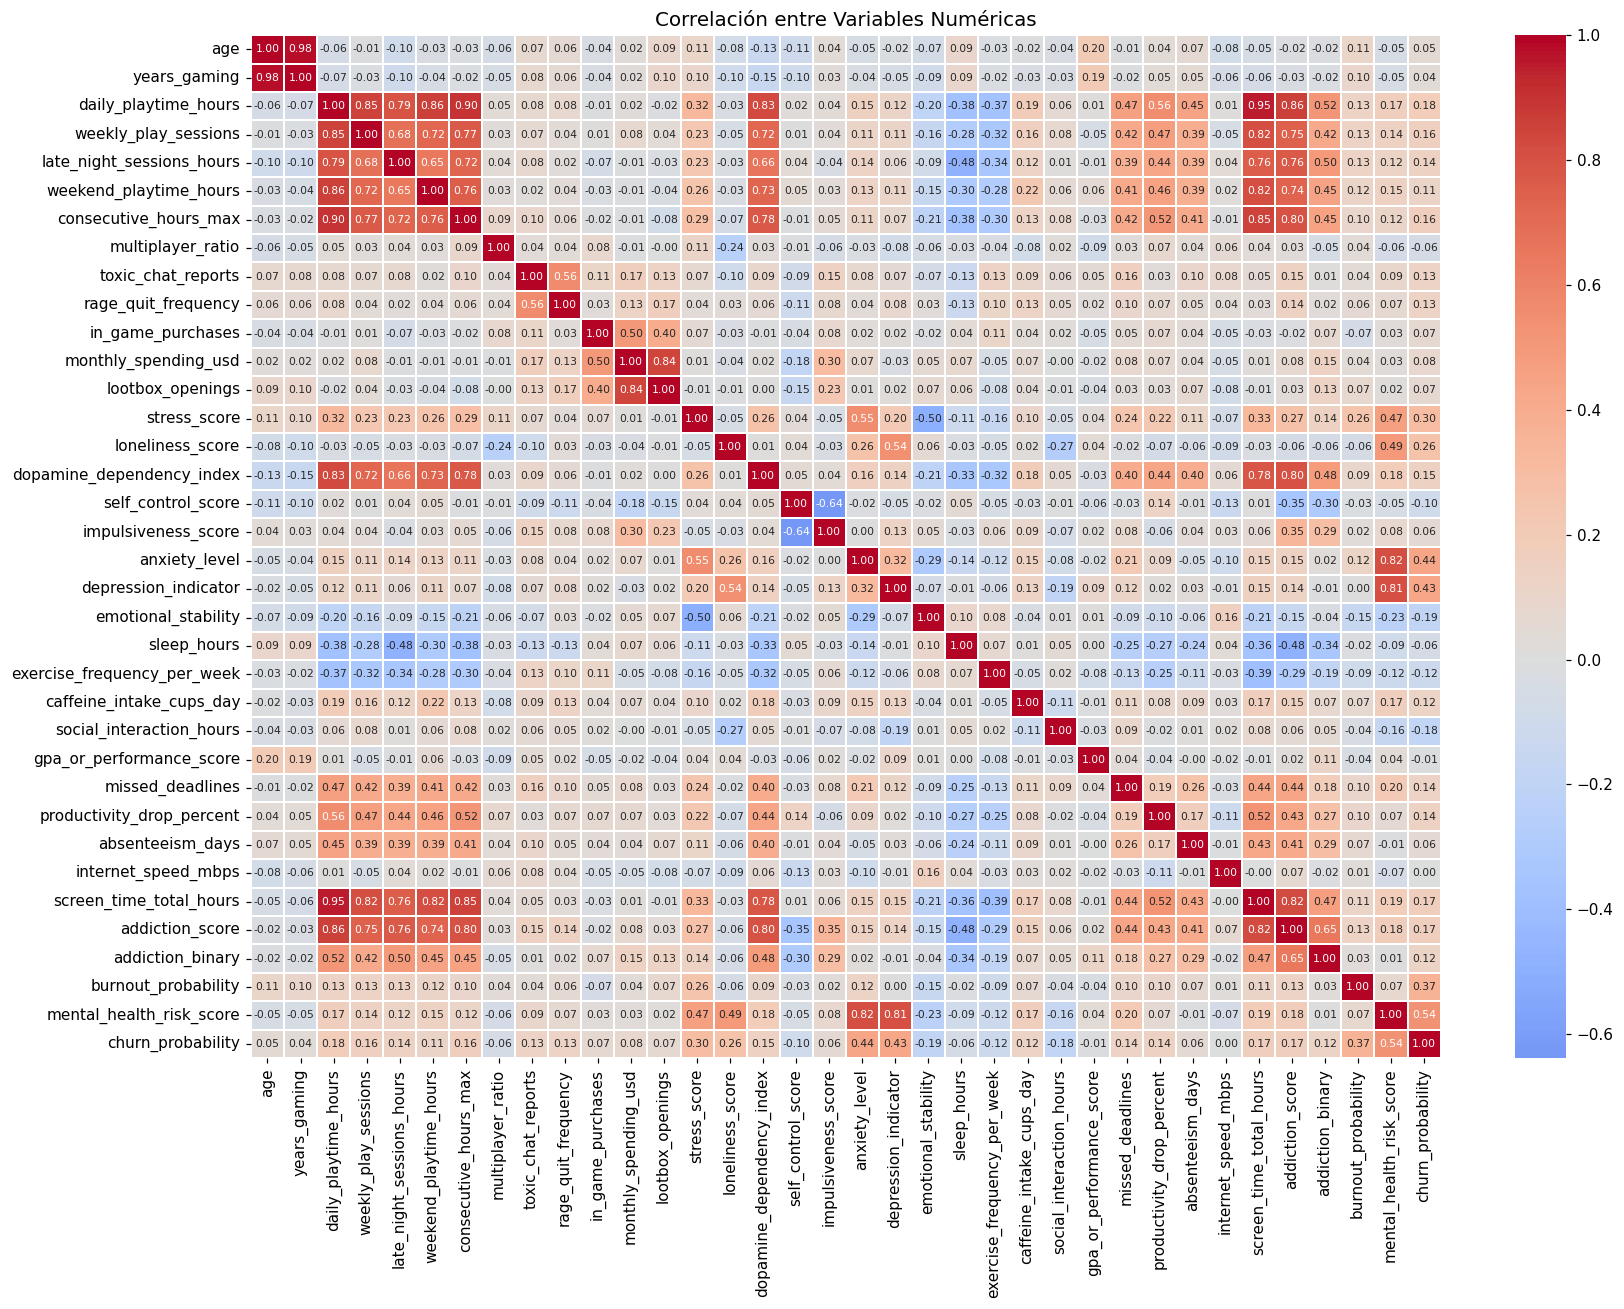


Correlaciones más fuertes con addiction_score:
daily_playtime_hours         0.864
screen_time_total_hours      0.824
consecutive_hours_max        0.799
dopamine_dependency_index    0.797
late_night_sessions_hours    0.764
weekly_play_sessions         0.747
weekend_playtime_hours       0.736
addiction_binary             0.650
sleep_hours                 -0.481
missed_deadlines             0.443


In [50]:
num_for_corr = df.select_dtypes(include='number').columns.tolist()

plt.figure(figsize=(16, 12), dpi=110)
sns.heatmap(df[num_for_corr].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.3, annot_kws={'size':7})
plt.title('Correlación entre Variables Numéricas', fontsize=13)
plt.tight_layout(); plt.show()

print('\nCorrelaciones más fuertes con addiction_score:')
corr_target = df[num_for_corr].corr()['addiction_score'].drop('addiction_score').sort_values(key=abs, ascending=False)
print(corr_target.head(10).round(3).to_string())

La unica correlacion fuerte negativa de el puntaje de adiccion es con el sueño, que es normal la gente desvelandose por los videojuegos.
Varias relaciones son bastante positivas y tienen congruencia con alguien que tiene cierto nivel de adiccion, por ejemplo la cantidad de horas jugadas, la cantida de seciones, se pasa de largo en la noche, horas de juegos fines de semana y etc.
No existe clara correlacion entre el puntaje de adiccion y variables de stress como la anciedad, depresion y estabilidad emocional

### I.9 — Visualizaciones multivariadas

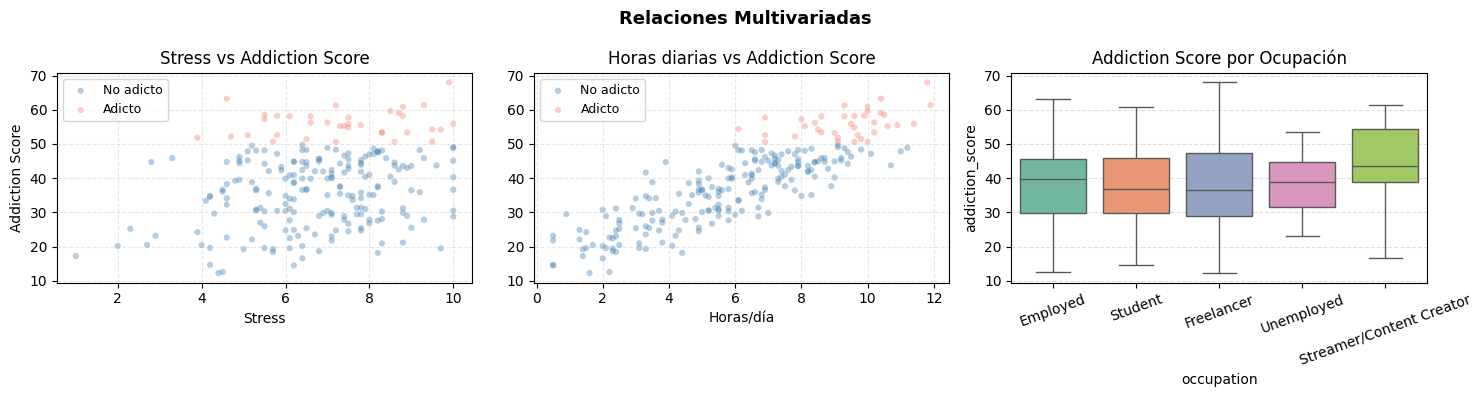

In [52]:
# salud mental vs adiccion
fig, axes = plt.subplots(1, 3, figsize=(15, 4), dpi=100)

# stress vs addiction_score
for val, color, label in [(0,'steelblue','No adicto'),(1,'salmon','Adicto')]:
    sub = df[df['addiction_binary']==val]
    axes[0].scatter(sub['stress_score'], sub['addiction_score'],
                    alpha=0.4, s=20, color=color, label=label, edgecolors='none')
axes[0].set_title('Stress vs Addiction Score'); axes[0].set_xlabel('Stress'); axes[0].set_ylabel('Addiction Score')
axes[0].legend(fontsize=9); axes[0].grid(linestyle='--', alpha=0.3)


for val, color, label in [(0,'steelblue','No adicto'),(1,'salmon','Adicto')]:
    sub = df[df['addiction_binary']==val]
    axes[1].scatter(sub['daily_playtime_hours'], sub['addiction_score'],
                    alpha=0.4, s=20, color=color, label=label, edgecolors='none')
axes[1].set_title('Horas diarias vs Addiction Score'); axes[1].set_xlabel('Horas/día')
axes[1].legend(fontsize=9); axes[1].grid(linestyle='--', alpha=0.3)

# boxplot ocupacion
sns.boxplot(data=df, x='occupation', y='addiction_score', ax=axes[2], palette='Set2')
axes[2].set_title('Addiction Score por Ocupación')
axes[2].tick_params(axis='x', rotation=20)
axes[2].grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Relaciones Multivariadas', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

No se encuentra un patron entre el stress y el puntaje de adiccion.
En el caso de la cantidad de horas dedicadas a jugar vs el puntaje de adiccion se aprecia fuertemente como estan correlacionados.
Dejando de lado a la gente que se dedica al medio del streaming, no parece haber una fuerte diferenciacion en la ocupacion al momento de ser adicto a los videojuegos

---
## Sección II — Resumen y hallazgos

In [55]:
print('=' * 65)
print('  INFORME FINAL — EDA GAMING ADDICTION DATASET')
print('=' * 65)

print(f'''
Dataset:
  Filas         : {len(df)}
  Columnas      : {df.shape[1]}
  Target        : addiction_binary (0=no adicto, 1=adicto)
  Fuente        : Kaggle — Gaming Addiction Dataset

Nulos:
  subscription_status  : columna eliminada
  addiction_severity   : imputado con moda
  depression_indicator : filas nulas eliminadas
  gpa_or_performance   : filas nulas eliminadas

Outliers: Mantenidos, casos de alto riesgo
''')

print(f'''
Hallazgos principales:
 * La mayoría de jugadores usa PC
 * Horas diarias de juego y stress_score poseen la mayor correlacion
 * El GPA/rendimiento cae conforme aumenta el addiction_score
 * Fuerte presencia masculina en la muestra

Desafíos:
 * Alta cantidad de columnas, requiere selección y alto poder de procesamiento
 * Dataset pequeño (250 filas)
 * Diversidad de enfoques
 * Gran cantidad de variables numericas no normales y con posibilidad de categorizacion

''')
print('=' * 65)

  INFORME FINAL — EDA GAMING ADDICTION DATASET

Dataset:
  Filas         : 229
  Columnas      : 47
  Target        : addiction_binary (0=no adicto, 1=adicto)
  Fuente        : Kaggle — Gaming Addiction Dataset

Nulos:
  subscription_status  : columna eliminada
  addiction_severity   : imputado con moda
  depression_indicator : filas nulas eliminadas
  gpa_or_performance   : filas nulas eliminadas

Outliers: Mantenidos, casos de alto riesgo


Hallazgos principales:
 * La mayoría de jugadores usa PC
 * Horas diarias de juego y stress_score poseen la mayor correlacion
 * El GPA/rendimiento cae conforme aumenta el addiction_score
 * Fuerte presencia masculina en la muestra

Desafíos:
 * Alta cantidad de columnas, requiere selección y alto poder de procesamiento
 * Dataset pequeño (250 filas)
 * Diversidad de enfoques
 * Gran cantidad de variables numericas no normales y con posibilidad de categorizacion




Resumir los principales hallazgos de cada EDA, destacando las características y desafíos únicos de cada conjunto de datos